## Read Tables

In [34]:
import pandas as pd
import numpy as np
from dotenv import load_dotenv
import os
import matplotlib.pyplot as plt


from sqlalchemy import create_engine, text

In [3]:
load_dotenv('../.env')

DB_USER     = os.getenv('DB_USER')
DB_PASSWORD = os.getenv('DB_PASSWORD')
DB_HOST     = os.getenv('DB_HOST')
DB_PORT     = os.getenv('DB_PORT')
DB_NAME     = os.getenv('DB_NAME')

engine = create_engine(
    f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)

In [4]:
with engine.connect() as connection:
    result = connection.execute(text("SELECT 1"))
    print(result.fetchone())

(1,)


In [5]:
users             = pd.read_sql("SELECT * FROM users", engine)
app_events        = pd.read_sql("SELECT * FROM app_events", engine)
loan_applications = pd.read_sql("SELECT * FROM loan_applications", engine)
installments      = pd.read_sql("SELECT * FROM installments", engine)
repayments        = pd.read_sql("SELECT * FROM repayments", engine)
dim_date          = pd.read_sql("SELECT * FROM dim_date", engine)

## Explore data

In [9]:
tables = {
    "users": users,
    "app_events": app_events,
    "loan_applications": loan_applications,
    "installments": installments,
    "repayments": repayments,
    "dim_date": dim_date
}

for name, df in tables.items():
    print(f"{name}: {df.shape}")

users: (10060, 7)
app_events: (218151, 6)
loan_applications: (8116, 7)
installments: (31494, 5)
repayments: (12434, 5)
dim_date: (809, 6)


### users

In [10]:
users.head()

,user_id,full_name,email,phone,city,acquisition_channel,signup_at
0,1,رضا ف.,re***@gmail.com,0907***0425,شیراز,organic,2026-03-06 14:13:08
1,2,سعید ا.,sa***@gmail.com,0947***2191,تهران,organic,2026-04-10 12:47:26
2,3,مریم ص.,ma***@gmail.com,0911***7840,تهران,sms_campaign,2026-05-03 09:39:56
3,4,علی ف.,al***@gmail.com,0986***8352,تهران,referral,2026-05-04 10:01:14
4,5,سعید ط.,sa***@gmail.com,0945***2255,رشت,google_ads,2026-05-21 15:28:39


In [12]:
users.info()

<class 'pandas.DataFrame'>
RangeIndex: 10060 entries, 0 to 10059
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   user_id              10060 non-null  int64         
 1   full_name            10060 non-null  str           
 2   email                10060 non-null  str           
 3   phone                10060 non-null  str           
 4   city                 10060 non-null  str           
 5   acquisition_channel  10060 non-null  str           
 6   signup_at            10060 non-null  datetime64[us]
dtypes: datetime64[us](1), int64(1), str(5)
memory usage: 550.3 KB


In [16]:
print(users.isna().sum())
print('duplicated rows:', users.duplicated().sum())

user_id                0
full_name              0
email                  0
phone                  0
city                   0
acquisition_channel    0
signup_at              0
dtype: int64
duplicated rows: 0


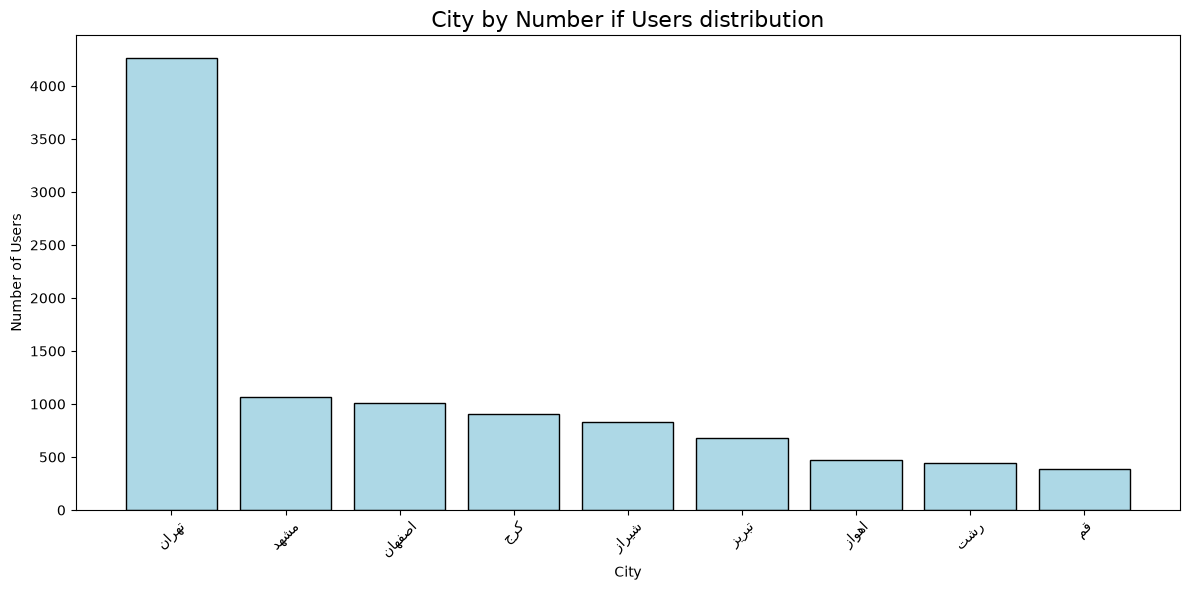

In [ ]:
# users['city'].value_counts().sort_values(ascending=False).plot(kind='bar')

plt.figure(figsize=(12, 6))
cities = users['city'].value_counts()
plt.bar(cities.index, cities.values, color='lightblue', edgecolor='black')

plt.title('City by Number if Users distribution', fontsize=16)
plt.xlabel('City')
plt.ylabel('Number of Users')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

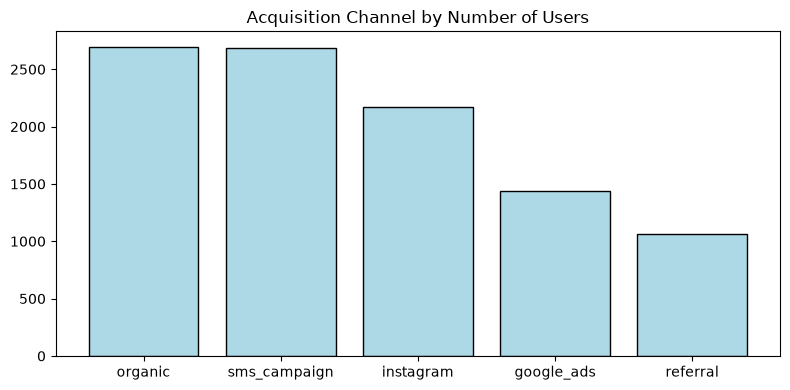

In [42]:
plt.figure(figsize=(8, 4))

acquisition_channel = users['acquisition_channel'].value_counts().sort_values(ascending=False)

plt.bar(x=acquisition_channel.index, height=acquisition_channel.values, color='lightblue', edgecolor='black')

plt.title('Acquisition Channel by Number of Users')

plt.tight_layout()
plt.show()

### app_events

In [43]:
app_events.head()

,event_id,user_id,session_id,event_name,event_time,platform
0,1,10018,s10018_0,app_open,2025-09-24 09:31:55,web
1,2,10018,s10018_0,view_loan_products,2025-09-24 09:32:25,web
2,3,10018,s10018_0,start_application,2025-09-24 09:32:55,web
3,4,10018,s10018_0,submit_application,2025-09-24 09:33:25,web
4,5,10013,s10013_0,app_open,2025-09-24 19:40:31,web


In [44]:
app_events.info()

<class 'pandas.DataFrame'>
RangeIndex: 218151 entries, 0 to 218150
Data columns (total 6 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   event_id    218151 non-null  int64         
 1   user_id     218151 non-null  int64         
 2   session_id  218151 non-null  str           
 3   event_name  218151 non-null  str           
 4   event_time  218151 non-null  datetime64[us]
 5   platform    218151 non-null  str           
dtypes: datetime64[us](1), int64(2), str(3)
memory usage: 10.0 MB


In [45]:
# Missing
print(app_events.isna().sum())
print()

# Duplicate
print('Duplicated rows:', app_events.duplicated().sum())

event_id      0
user_id       0
session_id    0
event_name    0
event_time    0
platform      0
dtype: int64

Duplicated rows: 0


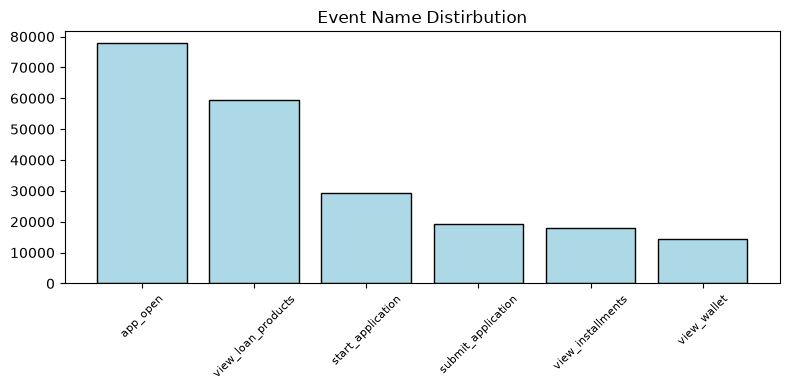

In [53]:
plt.figure(figsize=(8, 4))
events = app_events['event_name'].value_counts().sort_values(ascending=False)

plt.bar(
        x= events.index,
        height= events.values,
        color= 'lightblue',
        edgecolor= 'black'
    )

plt.xticks(rotation=45, fontsize=8)
plt.title('Event Name Distirbution')
plt.tight_layout()
plt.show()

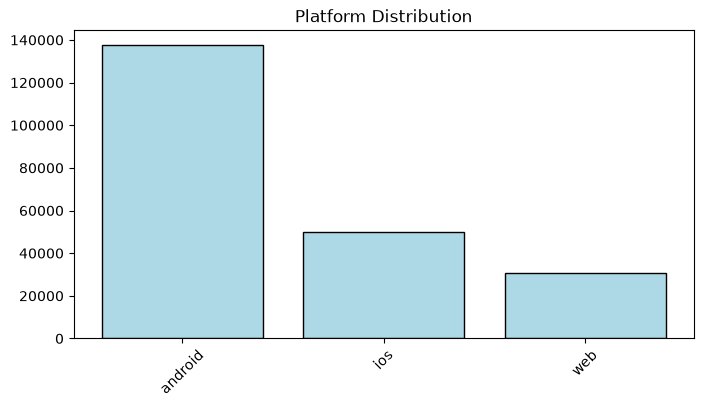

In [58]:
fig, ax = plt.subplots(figsize=(8, 4))
platform = app_events['platform'].value_counts().sort_values(ascending=False)
ax.bar(
    x= platform.index,
    height= platform.values,
    color= 'lightblue',
    edgecolor= 'black'
)
ax.set_title('Platform Distribution')
plt.xticks(rotation=45)
plt.show()

### loan_applications

In [59]:
loan_applications.head()

,application_id,user_id,created_at,status,requested_amount,n_installments,approved_at
0,1,2,2026-04-18 12:14:34,APPROVED,7300000,3.0,2026-04-20 06:37:37
1,2,3,2026-05-06 09:01:28,REJECTED,5000000,NaN,NaT
2,3,4,2026-05-09 06:57:35,APPROVED,14300000,12.0,2026-05-10 09:24:32
3,4,6,2026-06-20 06:53:26,PENDING,5000000,NaN,NaT
4,5,8,2026-03-15 17:00:25,REJECTED,14900000,NaN,NaT


In [60]:
loan_applications.info()

<class 'pandas.DataFrame'>
RangeIndex: 8116 entries, 0 to 8115
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   application_id    8116 non-null   int64         
 1   user_id           8116 non-null   int64         
 2   created_at        8116 non-null   datetime64[us]
 3   status            8116 non-null   str           
 4   requested_amount  8116 non-null   int64         
 5   n_installments    4839 non-null   float64       
 6   approved_at       4839 non-null   datetime64[us]
dtypes: datetime64[us](2), float64(1), int64(3), str(1)
memory usage: 444.0 KB


In [63]:
# missing values
print(loan_applications.isna().sum())

print()

# duplicated rows
print('duplicated rows:', loan_applications.duplicated().sum())

application_id         0
user_id                0
created_at             0
status                 0
requested_amount       0
n_installments      3277
approved_at         3277
dtype: int64

duplicated rows: 0


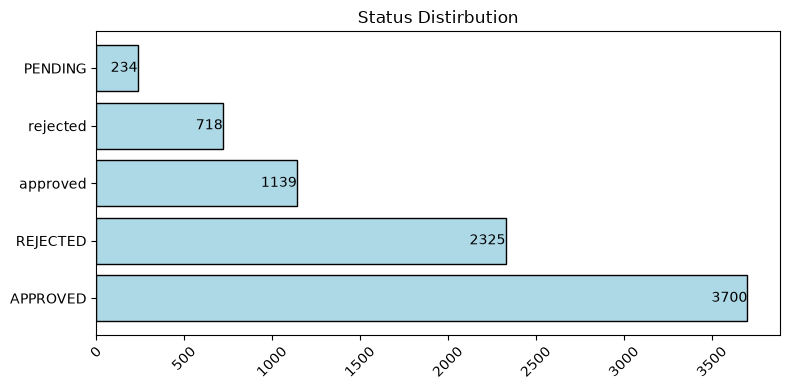

In [78]:
fig, ax = plt.subplots(figsize=(8, 4))
status = loan_applications['status'].value_counts().sort_values(ascending=False)

bars = ax.barh(
    y= status.index,
    width= status.values,
    color= 'lightblue',
    edgecolor= 'black'
)

for bar in bars:
    width = bar.get_width()
    ax.text(
        width,
        bar.get_y() + bar.get_height() / 2,
        f'{int(width)}',
        va='center',
        ha='right',
        fontsize=10
    )

ax.set_title('Status Distirbution')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

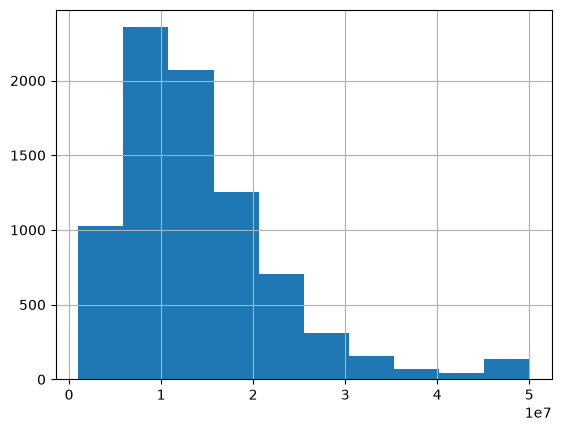

In [79]:
requested_amount = loan_applications['requested_amount'].hist()

### installments

### repayments

### dim_date

## Clean / preprocess